# Lab RL-2 · Actor-Critic in GridWorld

По мотивам Lecture 13 (слайды Actor-Critic / REINFORCE).

Три отдельные нейросети:
- **PolicyNet** — `p(a|s)` через softmax (Actor)
- **ValueNet** — `V(s)` как baseline (Critic)
- **RewardEstimator** — аппроксимирует дисконтированную награду (вспомогательная сеть)

Функции потерь:
```
L_policy = -Σ log p(a_t) · (R_t - V(s_t))     # advantage weighting
L_value  = MSE(V(s_t), R_t)                     # critic регрессия
L_reward = MSE(R̂(s_t), R_t)                    # reward estimator
```


In [39]:
import warnings
from dataclasses import dataclass
from typing import List

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from IPython.display import HTML
from matplotlib import animation


warnings.filterwarnings("ignore")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
torch.manual_seed(42)
np.random.seed(42)
plt.rcParams.update({"figure.dpi": 110})


Device: cuda


In [40]:
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))
print(torch.cuda.get_device_capability(0))

2.11.0+cu128
True
NVIDIA GeForce RTX 5070
(12, 0)


## 1. Среда (та же GridWorld, что в Lab 1)

In [46]:
GRID = """\
################
#A.....#.......#
#.###..#.#####.#
#...#..#.....#.#
###.#..#####.#.#
#...#......#.#.#
#.#######..#.#.#
#.......#..#...#
#.#####.#.###.##
#.#...#.#....D##
#.#.#.#.#####.##
#...#..........#
################""".strip()

ACTIONS = {0: (-1, 0), 1: (1, 0), 2: (0, -1), 3: (0, 1)}


class GridWorld:
    def __init__(self, raw=GRID):
        self.grid = [list(row) for row in raw.splitlines()]
        self.nrows = len(self.grid)
        self.ncols = len(self.grid[0])
        self.n_states = self.nrows * self.ncols
        self.n_actions = len(ACTIONS)
        self._start = self._find("A")
        self._goal = self._find("D")

    def _find(self, ch):
        for r, row in enumerate(self.grid):
            for c, cell in enumerate(row):
                if cell == ch: return (r, c)

    def _is_wall(self, r, c):
        return self.grid[r][c] == "#"

    def reset(self):
        self.pos = self._start
        return self._state_tensor()

    def _state_tensor(self):
        """
        Нормализованные координаты (r/H, c/W) — компактный 2D вход.
        Нейросеть не должна знать абсолютные индексы.
        """
        r, c = self.pos
        return torch.tensor(
            [r / self.nrows, c / self.ncols], dtype=torch.float32
        ).to(DEVICE)

    def step(self, action):
        dr, dc = ACTIONS[action]
        nr, nc = self.pos[0] + dr, self.pos[1] + dc
        if self._is_wall(nr, nc):
            return self._state_tensor(), -10.0, False
        self.pos = (nr, nc)
        if self.grid[nr][nc] == "D":
            return self._state_tensor(), +100.0, True
        return self._state_tensor(), -1.0, False


env = GridWorld()
s = env.reset()
print(f"State tensor: {s}  (shape {s.shape})")
print(f"States: {env.n_states}, Actions: {env.n_actions}")


State tensor: tensor([0.0769, 0.0625], device='cuda:0')  (shape torch.Size([2]))
States: 208, Actions: 4


## 2. Три нейросети

In [47]:
class PolicyNet(nn.Module):
    """
    Actor: p(a|s) — вероятности действий.
    """

    def __init__(self, n_actions: int, hidden: int = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
            nn.Linear(hidden, n_actions),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        logits = self.net(x)
        return F.softmax(logits, dim=-1)

    def dist(self, x: torch.Tensor):
        probs = self.forward(x)
        return torch.distributions.Categorical(probs=probs)

    def log_prob(self, x: torch.Tensor, action):
        if not torch.is_tensor(action):
            action = torch.tensor(action, dtype=torch.long, device=x.device)
        return self.dist(x).log_prob(action)

    def entropy(self, x: torch.Tensor):
        return self.dist(x).entropy()


class ValueNet(nn.Module):
    """
    Critic: V(s) — ожидаемая дисконтированная награда из s.
    """

    def __init__(self, hidden: int = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
            nn.Linear(hidden, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x).squeeze(-1)


class RewardEstimatorNet(nn.Module):
    """
    Вспомогательная сеть для диагностики: аппроксимирует returns.
    В policy update не участвует.
    """

    def __init__(self, hidden: int = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x).squeeze(-1)


policy_net = PolicyNet(env.n_actions).to(DEVICE)
value_net = ValueNet().to(DEVICE)
reward_est = RewardEstimatorNet().to(DEVICE)

opt_policy = optim.Adam(policy_net.parameters(), lr=1e-3)
opt_value = optim.Adam(value_net.parameters(), lr=2e-3)
opt_reward = optim.Adam(reward_est.parameters(), lr=2e-3)

total_params = sum(
    p.numel()
    for p in list(policy_net.parameters()) +
             list(value_net.parameters()) +
             list(reward_est.parameters())
)
print(f"Total parameters: {total_params}")

Total parameters: 51462


## 3. Rollout и дисконтированные награды

In [48]:
@dataclass
class Transition:
    state: torch.Tensor
    action: int
    reward: float


def collect_rollout(env: GridWorld, policy: PolicyNet,
                    max_steps: int = 300) -> List[Transition]:
    """
    Один эпизод: действия семплируем из текущей политики.
    """
    state = env.reset()
    trajectory = []

    for _ in range(max_steps):
        with torch.no_grad():
            action = policy.dist(state).sample().item()

        next_state, reward, done = env.step(action)
        trajectory.append(Transition(state, action, reward))
        state = next_state

        if done:
            break

    return trajectory


def compute_returns(rewards: List[float], gamma: float = 0.99) -> torch.Tensor:
    """
    R_t = r_t + γ·r_{t+1} + γ²·r_{t+2} + …
    ВАЖНО: returns здесь НЕ нормализуем.
    Нормализуется только advantage в train loop.
    """
    G = 0.0
    returns = []
    for r in reversed(rewards):
        G = r + gamma * G
        returns.insert(0, G)

    return torch.tensor(returns, dtype=torch.float32, device=DEVICE)

## 4. Цикл обучения

In [50]:
N_EPISODES = 400
GAMMA = 0.99
ENTROPY_COEFF = 1e-3
ROLLOUTS_PER_UPDATE = 8

history = {
    "reward": [],
    "loss_policy": [],
    "loss_value": [],
    "loss_reward_est": [],
    "entropy": [],
}

policy_snapshots = []
SNAP_EVERY = 10
max_steps = 100

for episode in range(N_EPISODES):
    batch_rewards = []
    batch_policy_losses = []
    batch_value_losses = []
    batch_reward_losses = []
    batch_entropies = []

    for _ in range(ROLLOUTS_PER_UPDATE):
        trajectory = collect_rollout(env, policy_net, max_steps=max_steps)
        rewards = [t.reward for t in trajectory]
        returns = compute_returns(rewards, GAMMA)

        states = torch.stack([t.state for t in trajectory])
        actions = torch.tensor([t.action for t in trajectory], dtype=torch.long, device=DEVICE)

        values = value_net(states)
        reward_pred = reward_est(states)

        advantages = returns - values.detach()
        if advantages.numel() > 1:
            advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

        dist = policy_net.dist(states)
        log_probs = dist.log_prob(actions)
        entropy = dist.entropy().mean()

        loss_policy = -(log_probs * advantages).mean() - ENTROPY_COEFF * entropy
        loss_value = F.mse_loss(values, returns)
        loss_reward = F.mse_loss(reward_pred, returns)

        batch_rewards.append(sum(rewards))
        batch_policy_losses.append(loss_policy)
        batch_value_losses.append(loss_value)
        batch_reward_losses.append(loss_reward)
        batch_entropies.append(entropy.detach())

    total_policy_loss = torch.stack(batch_policy_losses).mean()
    total_value_loss = torch.stack(batch_value_losses).mean()
    total_reward_loss = torch.stack(batch_reward_losses).mean()
    mean_entropy = torch.stack(batch_entropies).mean()

    opt_policy.zero_grad()
    total_policy_loss.backward()
    torch.nn.utils.clip_grad_norm_(policy_net.parameters(), max_norm=1.0)
    opt_policy.step()

    opt_value.zero_grad()
    total_value_loss.backward()
    torch.nn.utils.clip_grad_norm_(value_net.parameters(), max_norm=1.0)
    opt_value.step()

    opt_reward.zero_grad()
    total_reward_loss.backward()
    torch.nn.utils.clip_grad_norm_(reward_est.parameters(), max_norm=1.0)
    opt_reward.step()

    history["reward"].append(float(np.mean(batch_rewards)))
    history["loss_policy"].append(total_policy_loss.item())
    history["loss_value"].append(total_value_loss.item())
    history["loss_reward_est"].append(total_reward_loss.item())
    history["entropy"].append(mean_entropy.item())

    if episode % SNAP_EVERY == 0 or episode == N_EPISODES - 1:
        policy_snapshots.append((
            episode,
            {k: v.detach().cpu().clone() for k, v in policy_net.state_dict().items()}
        ))
        print(
            f"Ep {episode:4d} | "
            f"R={np.mean(batch_rewards):7.1f} | "
            f"L_π={total_policy_loss.item():.3f} | "
            f"L_V={total_value_loss.item():.3f} | "
            f"H={mean_entropy.item():.3f}"
        )

print(f"\nDone. Last-100 avg reward: {np.mean(history['reward'][-100:]):.1f}")

Ep    0 | R= -633.2 | L_π=-0.030 | L_V=72832.984 | H=1.277
Ep   10 | R= -462.4 | L_π=0.020 | L_V=35995.582 | H=1.231
Ep   20 | R= -515.4 | L_π=-0.006 | L_V=44632.762 | H=1.202
Ep   30 | R= -523.0 | L_π=-0.003 | L_V=43336.113 | H=1.228
Ep   40 | R= -429.4 | L_π=-0.029 | L_V=33351.164 | H=1.224
Ep   50 | R= -526.0 | L_π=-0.011 | L_V=45727.980 | H=1.256
Ep   60 | R= -511.5 | L_π=0.000 | L_V=40986.699 | H=1.266
Ep   70 | R= -421.4 | L_π=0.006 | L_V=27242.588 | H=1.233
Ep   80 | R= -534.2 | L_π=-0.004 | L_V=40088.000 | H=1.267
Ep   90 | R= -523.0 | L_π=0.006 | L_V=39184.023 | H=1.238
Ep  100 | R= -508.6 | L_π=0.002 | L_V=38053.398 | H=1.189
Ep  110 | R= -501.6 | L_π=-0.004 | L_V=32966.348 | H=1.236
Ep  120 | R= -429.9 | L_π=-0.034 | L_V=30502.895 | H=1.142
Ep  130 | R= -376.8 | L_π=-0.031 | L_V=28445.295 | H=1.191
Ep  140 | R= -460.2 | L_π=0.007 | L_V=30469.738 | H=1.171
Ep  150 | R= -416.5 | L_π=-0.028 | L_V=22450.312 | H=1.141
Ep  160 | R= -490.4 | L_π=-0.055 | L_V=27090.148 | H=1.060
Ep 

## 5. Кривые обучения

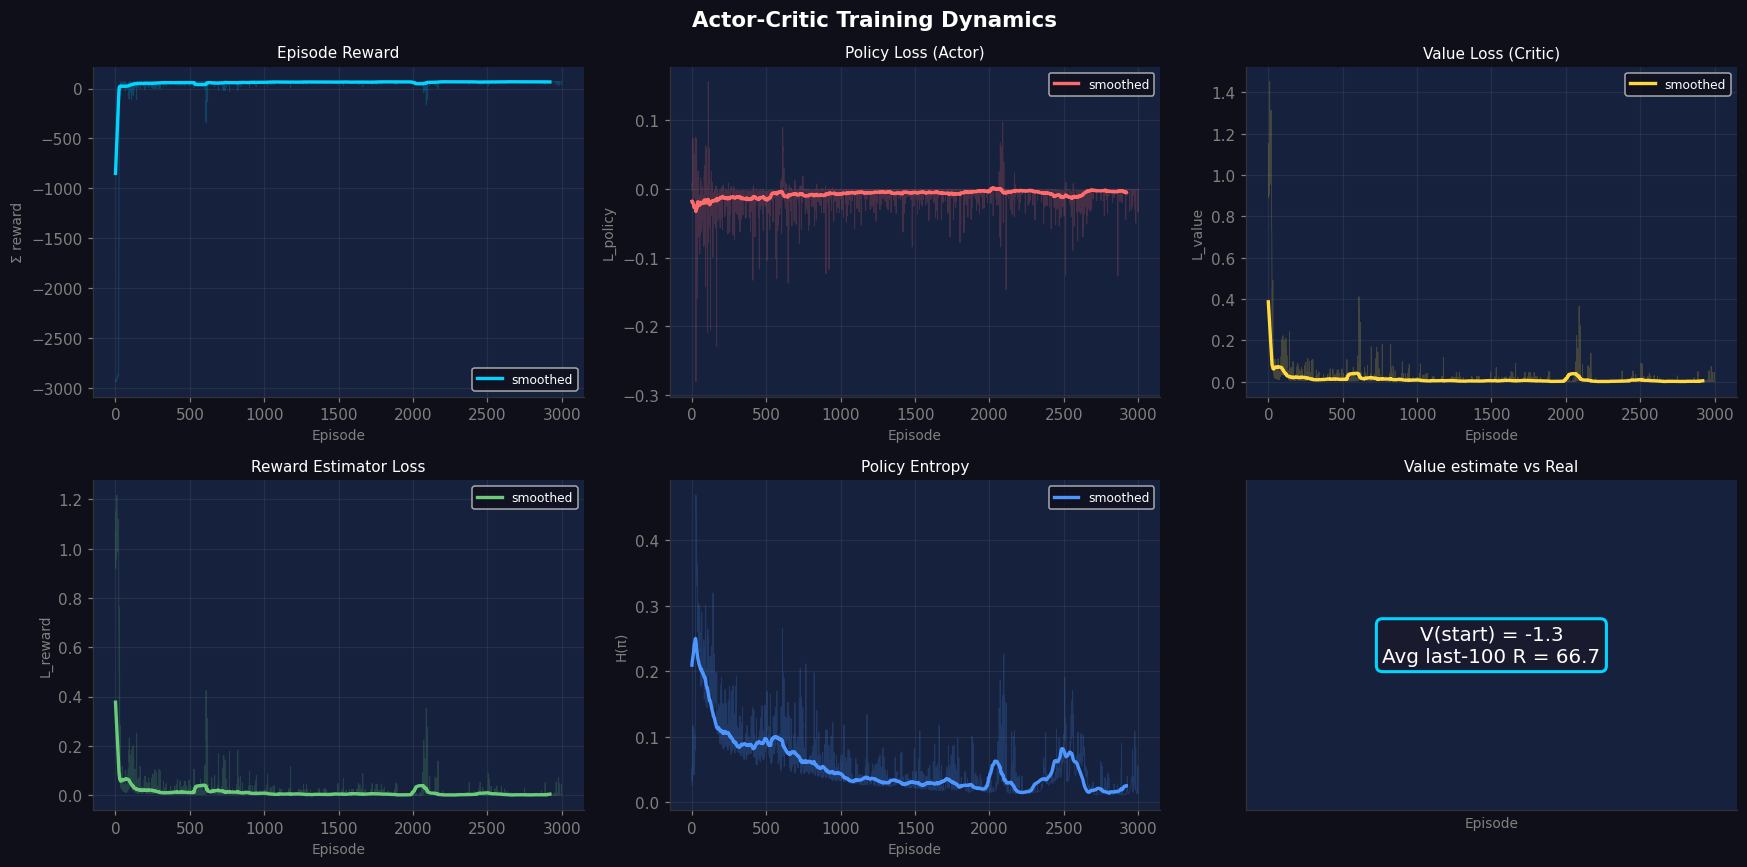

In [19]:
def smooth(x, w=80):
    return np.convolve(x, np.ones(w) / w, mode='valid')


fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.patch.set_facecolor("#0f0f1a")
fig.suptitle("Actor-Critic Training Dynamics", color="white",
             fontsize=14, fontweight="bold")

palette = ["#00d4ff", "#ff6b6b", "#ffd93d", "#6bcb77", "#4d96ff", "#ff922b"]


def styled_ax(ax, title, ylabel="", xlabel="Episode"):
    ax.set_facecolor("#16213e")
    ax.tick_params(colors="gray")
    ax.spines[["top", "right"]].set_visible(False)
    for spine in ax.spines.values(): spine.set_color("#333")
    ax.set_title(title, color="white", fontsize=10)
    ax.set_ylabel(ylabel, color="gray", fontsize=9)
    ax.set_xlabel(xlabel, color="gray", fontsize=9)
    ax.grid(alpha=0.15, color="gray")


keys = ["reward", "loss_policy", "loss_value", "loss_reward_est", "entropy"]
titles = ["Episode Reward", "Policy Loss (Actor)",
          "Value Loss (Critic)", "Reward Estimator Loss", "Policy Entropy"]
ylabels = ["Σ reward", "L_policy", "L_value", "L_reward", "H(π)"]

for i, (key, title, ylabel) in enumerate(zip(keys, titles, ylabels)):
    ax = axes[i // 3][i % 3]
    data = history[key]
    ax.plot(data, alpha=0.2, color=palette[i], linewidth=0.6)
    s = smooth(data)
    ax.plot(range(len(s)), s, color=palette[i], linewidth=2.2, label="smoothed")
    styled_ax(ax, title, ylabel)
    ax.legend(fontsize=8, facecolor="#0f0f1a", labelcolor="white",
              framealpha=0.8)

# 6-й: сравнение V(s_start) vs реальная награда
ax = axes[1][2]
with torch.no_grad():
    s_start = env.reset()
    # V(start) не менялся в истории — запустим заново по снимкам
    policy_copy = PolicyNet(env.n_actions).to("cpu")
    value_copy = ValueNet().to("cpu")
    value_copy.load_state_dict(value_net.state_dict())
    v_start = value_net(s_start).item()

ax.text(0.5, 0.5, f"V(start) = {v_start:.1f}\nAvg last-100 R = {np.mean(history['reward'][-100:]):.1f}",
        transform=ax.transAxes, ha="center", va="center",
        color="white", fontsize=13,
        bbox=dict(boxstyle="round", fc="#1a1a2e", ec=palette[0], lw=2))
styled_ax(ax, "Value estimate vs Real", "")
ax.set_xticks([]);
ax.set_yticks([])

plt.tight_layout()
plt.show()


## 6. Визуализация политики по клеткам

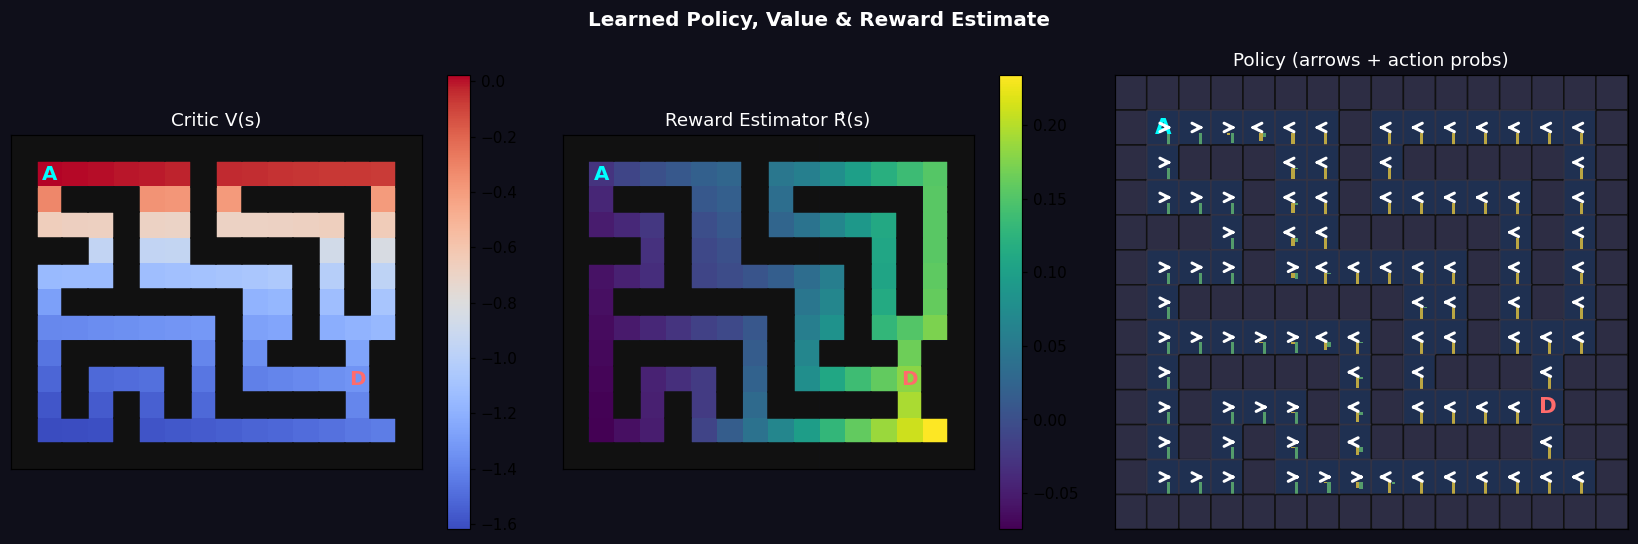

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.patch.set_facecolor("#0f0f1a")
fig.suptitle("Learned Policy, Value & Reward Estimate", color="white",
             fontsize=13, fontweight="bold")


def make_grid_maps():
    """Для каждой незастроенной клетки считаем p(a), V(s), R̂(s)"""
    H, W = env.nrows, env.ncols
    best_action = np.full((H, W), -1)
    value_map = np.full((H, W), np.nan)
    reward_map = np.full((H, W), np.nan)

    for r in range(H):
        for c in range(W):
            if env.grid[r][c] == "#": continue
            s = torch.tensor([r / H, c / W], dtype=torch.float32).to(DEVICE)
            with torch.no_grad():
                probs = policy_net(s)
                V = value_net(s).item()
                R_hat = reward_est(s).item()
            best_action[r, c] = probs.argmax().item()
            value_map[r, c] = V
            reward_map[r, c] = R_hat
    return best_action, value_map, reward_map


best_action, value_map, reward_map = make_grid_maps()

arrow_map = {0: (0, -0.38), 1: (0, 0.38), 2: (-0.38, 0), 3: (0.38, 0)}
ARROW_NAMES = {0: "↑", 1: "↓", 2: "←", 3: "→"}

for ax_idx, (data, title, cmap) in enumerate([
    (value_map, "Critic V(s)", "coolwarm"),
    (reward_map, "Reward Estimator R̂(s)", "viridis"),
]):
    ax = axes[ax_idx]
    ax.set_facecolor("#16213e")
    im = ax.imshow(data, cmap=cmap, interpolation="nearest", aspect="equal")
    plt.colorbar(im, ax=ax)

    for r in range(env.nrows):
        for c in range(env.ncols):
            if env.grid[r][c] == "#":
                ax.add_patch(mpatches.Rectangle((c - .5, r - .5), 1, 1, color="#111"))
            elif env.grid[r][c] == "D":
                ax.text(c, r, "D", ha="center", va="center",
                        fontsize=13, color="#ff6b6b", fontweight="bold")
            elif env.grid[r][c] == "A":
                ax.text(c, r, "A", ha="center", va="center",
                        fontsize=13, color="cyan", fontweight="bold")

    ax.set_title(title, color="white");
    ax.set_xticks([]);
    ax.set_yticks([])

# Политика со стрелками
ax = axes[2]
ax.set_facecolor("#16213e")
ax.set_xlim(-0.5, env.ncols - 0.5)
ax.set_ylim(env.nrows - 0.5, -0.5)

for r in range(env.nrows):
    for c in range(env.ncols):
        ch = env.grid[r][c]
        if ch == "#":
            ax.add_patch(mpatches.FancyBboxPatch((c - .45, r - .45), .9, .9,
                                                 boxstyle="round,pad=0.05", fc="#2d2d44", ec="#111"))
            continue
        ax.add_patch(mpatches.FancyBboxPatch((c - .45, r - .45), .9, .9,
                                             boxstyle="round,pad=0.05", fc="#1f3051", ec="#334"))
        if ch == "D":
            ax.text(c, r, "D", ha="center", va="center", fontsize=14, color="#ff6b6b", fontweight="bold")
            continue
        if ch == "A":
            ax.text(c, r, "A", ha="center", va="center", fontsize=14, color="cyan", fontweight="bold")

        s = torch.tensor([r / env.nrows, c / env.ncols], dtype=torch.float32).to(DEVICE)
        with torch.no_grad():
            probs = policy_net(s).cpu().numpy()

        # рисуем стрелку лучшего действия
        best_a = int(probs.argmax())
        dx, dy = arrow_map[best_a]
        ax.annotate("", xy=(c + dx, r + dy), xytext=(c, r),
                    arrowprops=dict(arrowstyle="->", color="white",
                                    lw=2, mutation_scale=14))
        # мини-гистограмма вероятностей (4 действия)
        colors_act = ["#00d4ff", "#ff6b6b", "#ffd93d", "#6bcb77"]
        for ai, (prob, col) in enumerate(zip(probs, colors_act)):
            bar_dx = (ai - 1.5) * 0.12
            ax.bar(c + bar_dx, prob * 0.35, width=0.1, bottom=r + 0.15,
                   color=col, alpha=0.7)

ax.set_title("Policy (arrows + action probs)", color="white")
ax.set_xticks([]);
ax.set_yticks([])

plt.tight_layout()
plt.show()


## 7. Анимация: как менялась политика в процессе обучения

In [51]:
def get_policy_path(state_dict, max_steps=300):
    """Жадный путь по сохранённой политике"""
    net = PolicyNet(env.n_actions).to("cpu")
    net.load_state_dict(state_dict)
    net.eval()

    env2 = GridWorld()
    state = env2.reset().cpu()
    path = [env2.pos]
    for _ in range(max_steps):
        with torch.no_grad():
            probs = net(state)
        action = probs.argmax().item()
        next_s, _, done = env2.step(action)
        path.append(env2.pos)
        state = next_s.cpu()
        if done: break
    return path


def draw_policy_frame(ax, state_dict, episode, reward_history):
    """Рисует: карта + путь + мини-plot наград"""
    ax.clear()
    ax.set_facecolor("#16213e")

    net = PolicyNet(env.n_actions).to("cpu")
    net.load_state_dict(state_dict)
    net.eval()

    # карта
    for r in range(env.nrows):
        for c in range(env.ncols):
            ch = env.grid[r][c]
            fc = "#2d2d44" if ch == "#" else "#1f3051"
            ax.add_patch(mpatches.FancyBboxPatch((c - .45, r - .45), .9, .9,
                                                 boxstyle="round,pad=0.05", fc=fc, ec="#222"))
            if ch == "D":
                ax.text(c, r, "D", ha="center", va="center",
                        fontsize=14, color="#ff6b6b", fontweight="bold", zorder=5)
            elif ch == "A":
                ax.text(c, r, "A", ha="center", va="center",
                        fontsize=14, color="cyan", fontweight="bold", zorder=5)

    # стрелки политики
    for r in range(env.nrows):
        for c in range(env.ncols):
            if env.grid[r][c] in ("#", "D"): continue
            s = torch.tensor([r / env.nrows, c / env.ncols], dtype=torch.float32)
            with torch.no_grad():
                probs = net(s)
            ba = probs.argmax().item()
            dx, dy = arrow_map[ba]
            confidence = probs[ba].item()
            alpha = 0.3 + 0.7 * confidence
            ax.annotate("", xy=(c + dx * 0.8, r + dy * 0.8), xytext=(c, r),
                        arrowprops=dict(arrowstyle="->",
                                        color=plt.cm.cool(confidence),
                                        lw=1.5, mutation_scale=10,
                                        alpha=alpha))

    # маршрут
    path = get_policy_path(state_dict)
    if len(path) > 1:
        rows_p = [p[0] for p in path]
        cols_p = [p[1] for p in path]
        for i in range(len(path) - 1):
            t = i / max(len(path) - 2, 1)
            ax.plot([cols_p[i], cols_p[i + 1]], [rows_p[i], rows_p[i + 1]],
                    color=plt.cm.YlOrRd(0.3 + 0.7 * t), linewidth=3,
                    solid_capstyle="round", zorder=4, alpha=0.9)

    ax.set_xlim(-0.5, env.ncols - 0.5)
    ax.set_ylim(env.nrows - 0.5, -0.5)
    ax.set_xticks([]);
    ax.set_yticks([])

    ep_reward = np.mean(reward_history[max(0, episode - 50):episode + 1]) if episode > 0 else 0
    ax.set_title(f"Episode {episode}  |  avg-50 R = {ep_reward:.0f}",
                 color="white", fontsize=10)


fig, (ax_main, ax_curve) = plt.subplots(1, 2, figsize=(14, 6),
                                        gridspec_kw={"width_ratios": [1.3, 1]})
fig.patch.set_facecolor("#0f0f1a")
ax_curve.set_facecolor("#16213e")

# инициализируем кривую наград
rw_line, = ax_curve.plot([], [], color="#00d4ff", linewidth=2, label="reward")
smooth_line, = ax_curve.plot([], [], color="#ff6b6b", linewidth=2.5,
                             label="MA-50", linestyle="--")
ax_curve.set_xlim(0, N_EPISODES)
ax_curve.set_ylim(min(history["reward"]) - 5, max(history["reward"]) + 5)
ax_curve.set_xlabel("Episode", color="gray")
ax_curve.set_ylabel("Reward", color="gray")
ax_curve.set_title("Reward over time", color="white")
ax_curve.grid(alpha=0.15, color="gray")
ax_curve.spines[["top", "right"]].set_visible(False)
for sp in ax_curve.spines.values(): sp.set_color("#333")
ax_curve.tick_params(colors="gray")
ax_curve.legend(facecolor="#0f0f1a", labelcolor="white", fontsize=9)
vline = ax_curve.axvline(0, color="#ffd93d", linewidth=1.5, alpha=0.7)


def anim_update(frame_idx):
    ep, sd = policy_snapshots[frame_idx]
    draw_policy_frame(ax_main, sd, ep, history["reward"])

    # кривая наград до текущего эпизода
    xs = list(range(ep + 1))
    ys = history["reward"][:ep + 1]
    rw_line.set_data(xs, ys)

    if len(ys) >= 50:
        sw = np.convolve(ys, np.ones(50) / 50, mode="valid")
        smooth_line.set_data(range(49, ep + 1), sw)

    vline.set_xdata([ep, ep])
    fig.suptitle("Actor-Critic: Policy Evolution", color="white",
                 fontsize=13, fontweight="bold")
    return [rw_line, smooth_line, vline]


# первый кадр
draw_policy_frame(ax_main, policy_snapshots[0][1], 0, history["reward"])
plt.tight_layout()

anim = animation.FuncAnimation(fig, anim_update, frames=len(policy_snapshots),
                               interval=700, blit=False)
plt.close()
HTML(anim.to_jshtml())


## 8. Финальный маршрут и сравнение с Q-table

Actor-Critic path length: 6 steps


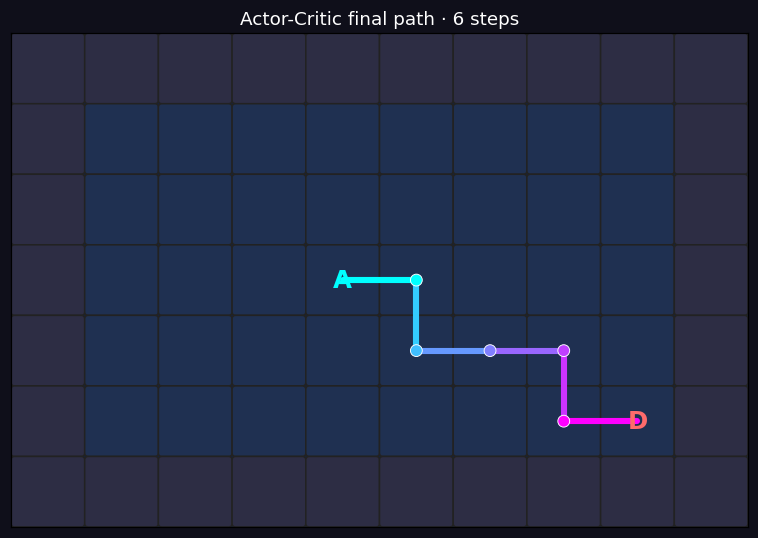

In [12]:
policy_net.eval()
env_f = GridWorld()
state = env_f.reset()
path_ac = [env_f.pos]
for _ in range(300):
    with torch.no_grad():
        probs = policy_net(state)
    action = probs.argmax().item()
    next_s, _, done = env_f.step(action)
    path_ac.append(env_f.pos)
    state = next_s
    if done: break

print(f"Actor-Critic path length: {len(path_ac) - 1} steps")

fig, ax = plt.subplots(figsize=(7, 5))
fig.patch.set_facecolor("#0f0f1a")
ax.set_facecolor("#16213e")
ax.set_xlim(-0.5, env.ncols - 0.5)
ax.set_ylim(env.nrows - 0.5, -0.5)

for r in range(env.nrows):
    for c in range(env.ncols):
        ch = env.grid[r][c]
        fc = "#2d2d44" if ch == "#" else "#1f3051"
        ax.add_patch(mpatches.FancyBboxPatch((c - .45, r - .45), .9, .9,
                                             boxstyle="round,pad=0.05", fc=fc, ec="#222"))
        if ch == "D":
            ax.text(c, r, "D", ha="center", va="center",
                    fontsize=16, color="#ff6b6b", fontweight="bold", zorder=5)

rows_p = [p[0] for p in path_ac]
cols_p = [p[1] for p in path_ac]
for i in range(len(path_ac) - 1):
    t = i / max(len(path_ac) - 2, 1)
    ax.plot([cols_p[i], cols_p[i + 1]], [rows_p[i], rows_p[i + 1]],
            color=plt.cm.cool(t), linewidth=4,
            solid_capstyle="round", zorder=3)

ax.scatter(cols_p[1:-1], rows_p[1:-1], s=60, c=range(len(path_ac) - 2),
           cmap="cool", zorder=4, edgecolors="white", linewidths=0.6)
ax.text(cols_p[0], rows_p[0], "A", ha="center", va="center",
        fontsize=16, color="cyan", fontweight="bold", zorder=6)

ax.set_xticks([]);
ax.set_yticks([])
ax.set_title(f"Actor-Critic final path · {len(path_ac) - 1} steps",
             color="white", fontsize=12)
plt.tight_layout()
plt.show()


## Итоги

| | Q-Table | Actor-Critic |
|---|---|---|
| Память | O(S·A) | O(params) |
| Масштабируемость | Плохая | Хорошая |
| Сходимость | Стабильная | Может быть нестабильной |
| Расширяемость | Нет | Continuous action space, etc. |
| Baseline | Нет | V(s) — снижает дисперсию |
| Сети | — | PolicyNet + ValueNet + RewardEst |

**Ключевая идея Actor-Critic:** Critic учит PolicyNet не просто "эта награда хорошая",  
а "эта награда _лучше ожидаемого_" (advantage = R - V(s)) — это снижает дисперсию градиента.
